# Parte 4 · Optimización

**Lo que pide el enunciado (§8) y dónde está:**

| Pide | Dónde |
|---|---|
| Comparar al menos dos optimizadores, resto constante | SGD, SGD+momentum, Adam, AdamW sobre ResNet-18 (§1) |
| Velocidad de convergencia, comportamiento de la pérdida, estabilidad | §2 (curvas, norma del gradiente) |
| Rendimiento en validación, generalización | §2 (tabla, brecha train–val) |
| Sensibilidad al learning rate | §3 (3 lr para SGD+momentum y 3 para Adam) |
| Discutir **por qué** se comportan distinto | §4 |
| Gráficos train/val loss y accuracy vs época | §2 |

Código: `entrenamiento.crear_optimizador`.

In [1]:
from analisis import *          # cargar resultados, tablas, curvas (ver analisis.py)
R = resultados()
print("terminados:", " ".join(R))

terminados: E01 E02 E03 E04 E05 E06 E07 E08 E09 E10 E11 E12 A1 A2 A3 A4 A5 A6 T1 T2 T3 T4 L2 L3 L4 L5


## 1. Definición: referencia E03 (SGD + momentum Nesterov 0.9, lr 0.1)

In [2]:
definiciones([(i, "E03") for i in ["E06", "E07", "E08", "E09", "E10", "E11", "E12"]])

,referencia,descripción,estado,cambios
ID,,,,
E06,E03,"SGD sin momentum, lr 0.1",terminado,optimizador: sgdm → sgd
E07,E03,"SGD+momentum, lr 0.02",terminado,lr: 0.1 → 0.02
E08,E03,"SGD+momentum, lr 0.5",terminado,lr: 0.1 → 0.5
E09,E03,"Adam, lr 1e-3",terminado,optimizador: sgdm → adam; lr: 0.1 → 0.001
E10,E03,"Adam, lr 1e-4",terminado,optimizador: sgdm → adam; lr: 0.1 → 0.0001
E11,E03,"Adam, lr 1e-2",terminado,optimizador: sgdm → adam; lr: 0.1 → 0.01
E12,E03,"AdamW, lr 1e-3, wd 0.05 (desacoplado)",terminado,optimizador: sgdm → adamw; lr: 0.1 → 0.001; we...


Todo lo demás es idéntico: ResNet-18 desde cero, batch 256, 16 épocas, warmup de 1 época + coseno,
weight decay 5e-5 (salvo E12), aumento básico, semilla 42.

## 2. Optimizadores con su learning rate habitual

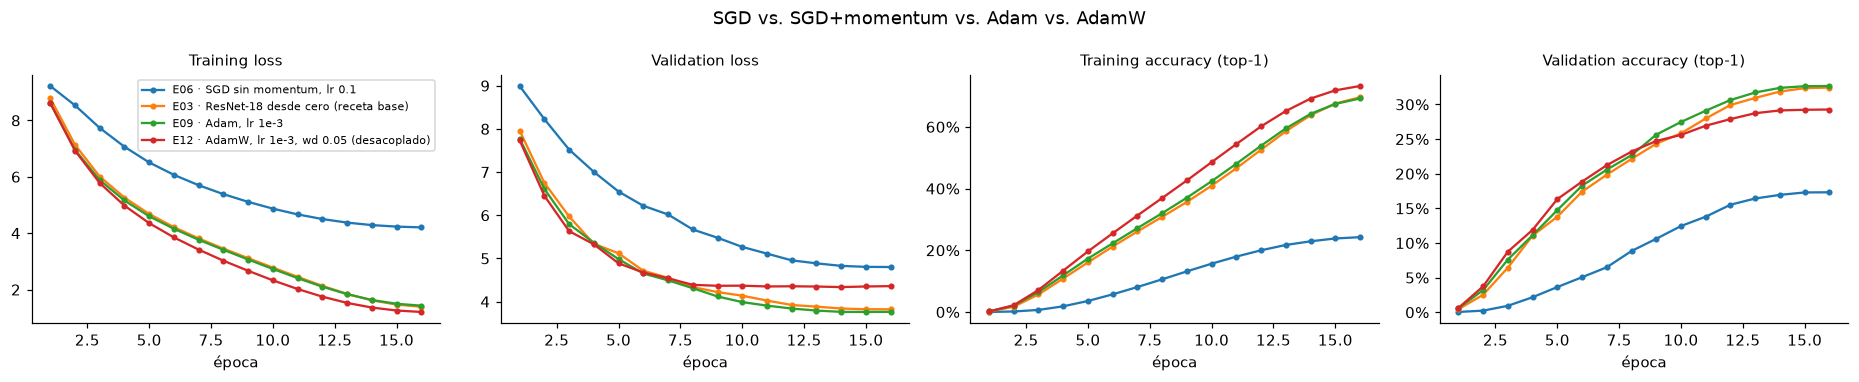

,descripción,top1,top5,f1_macro,f1_weighted,train_top1,brecha_top1,brecha_loss,mejor_ep,épocas,img_s,min_total,gpu,época 90%,top1 época 3,grad medio
ID,,,,,,,,,,,,,,,,
E06,"SGD sin momentum, lr 0.1",17.3%,35.6%,15.8%,15.8%,24.3%,7.0%,0.60,16,16,7062,19,A100 MIG 3g.20gb,13,0.9%,4.4
E03,ResNet-18 desde cero (receta base),32.4%,54.5%,31.8%,31.8%,69.6%,37.2%,2.43,16,16,4750,27,RTX A6000,12,6.4%,2.5
E07,"SGD+momentum, lr 0.02",25.9%,46.9%,24.8%,24.8%,40.6%,14.7%,1.07,16,16,6901,19,A100 MIG 3g.20gb,12,2.7%,4.1
E08,"SGD+momentum, lr 0.5",34.7%,56.6%,34.3%,34.3%,81.3%,46.6%,3.05,16,16,6902,19,A100 MIG 3g.20gb,14,6.5%,1.6
E09,"Adam, lr 1e-3",32.6%,54.8%,32.0%,32.0%,69.2%,36.6%,2.33,16,16,6774,20,A100 MIG 3g.20gb,12,7.6%,3.8
E10,"Adam, lr 1e-4",15.6%,32.9%,14.1%,14.1%,23.5%,7.8%,0.72,15,16,6770,20,A100 MIG 3g.20gb,12,2.4%,14.6
E11,"Adam, lr 1e-2",16.7%,34.5%,15.3%,15.3%,21.3%,4.6%,0.45,16,16,6773,20,A100 MIG 3g.20gb,14,1.4%,1.2
E12,"AdamW, lr 1e-3, wd 0.05 (desacoplado)",29.3%,50.5%,28.7%,28.7%,73.2%,44.0%,3.15,16,16,6790,20,A100 MIG 3g.20gb,11,8.7%,4.1


In [3]:
curvas(R, ["E06", "E03", "E09", "E12"], "SGD vs. SGD+momentum vs. Adam vs. AdamW")
t = tabla(R, ["E06", "E03", "E07", "E08", "E09", "E10", "E11", "E12"])
if len(t):
    t["época 90%"] = [epoca_para(R, i) for i in t.index]
    t["top1 época 3"] = [R[i]["hist"].val_top1.iloc[2] for i in t.index]
    t["grad medio"] = [R[i]["hist"].grad_norma_media.mean() for i in t.index]
t.drop(columns=["params_M", "entrenables_M", "GFLOPs"]).style.format(FMT | {"top1 época 3": "{:.1%}", "grad medio": "{:.1f}"}) if len(t) else None

## 3. Sensibilidad al learning rate y estabilidad

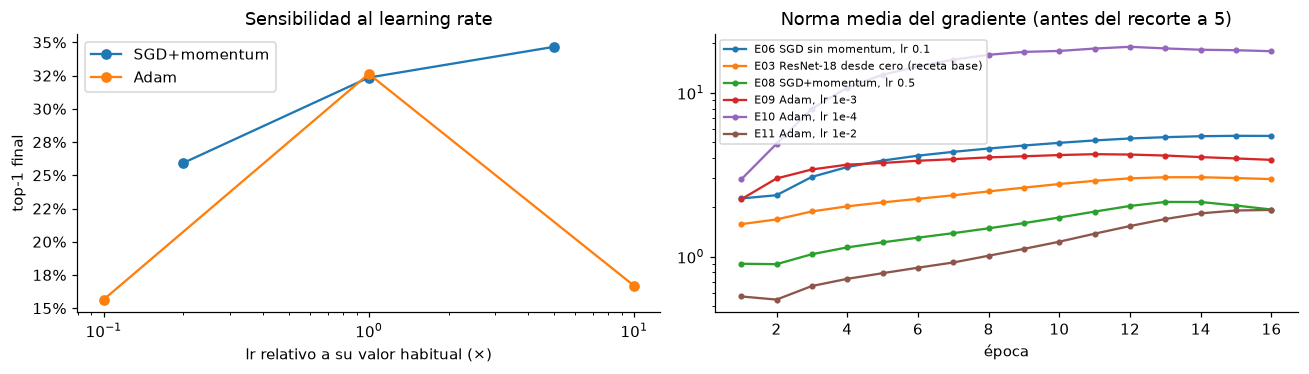

In [4]:
barr = {"SGD+momentum": {0.02: "E07", 0.1: "E03", 0.5: "E08"}, "Adam": {1e-4: "E10", 1e-3: "E09", 1e-2: "E11"}}
fig, axs = plt.subplots(1, 2, figsize=(12, 3.5))
for nom, d in barr.items():
    lrs = [lr for lr, i in d.items() if i in R]
    rel = np.array(lrs) / lrs[len(lrs) // 2] if lrs else []
    axs[0].plot(rel, [R[d[lr]]["resumen"]["val_top1"] for lr in lrs], "o-", label=nom)
axs[0].set_xscale("log"); axs[0].set_xlabel("lr relativo a su valor habitual (×)")
axs[0].set_ylabel("top-1 final"); axs[0].legend(); axs[0].set_title("Sensibilidad al learning rate")
axs[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
for i in ["E06", "E03", "E08", "E09", "E10", "E11"]:
    if i in R:
        axs[1].plot(R[i]["hist"].epoca, R[i]["hist"].grad_norma_media, ".-", label=f"{i} {POR_ID[i].descripcion}")
axs[1].set_yscale("log"); axs[1].set_title("Norma media del gradiente (antes del recorte a 5)")
axs[1].set_xlabel("época"); axs[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 4. Lectura: ¿por qué se comportan distinto?

**Resultados clave** (top-1 de validación, ResNet-18, 16 épocas):

| | lr bajo | lr habitual | lr alto |
|---|---|---|---|
| SGD + momentum | 25,9 % (0,02) | 32,4 % (0,1) | **34,7 %** (0,5) |
| Adam | 15,6 % (1e-4) | 32,6 % (1e-3) | 16,7 % (1e-2) |
| SGD sin momentum | | 17,3 % (0,1) | |
| AdamW (wd 0,05) | | 29,3 % (1e-3) | |

* **El momentum es decisivo:** SGD sin momentum (E06) se queda en 17,3 %, casi la mitad que con momentum
  al mismo lr. El momentum acumula una media exponencial de gradientes: amortigua el ruido del mini-lote y
  multiplica el paso efectivo por ≈ 1/(1−β) = 10. De hecho, SGD sin momentum a lr 0,1 equivale a
  SGD+momentum a lr ≈ 0,01, y queda por debajo de E07 (lr 0,02), en coherencia con esa lectura.
* **SGD+momentum tolera un rango de lr amplio:** sobre un rango de 25× (0,02 → 0,5) varía 9 pp, y el
  mejor es el **más alto**: la receta base (0,1) no era óptima. Un lr grande añade ruido a la trayectoria,
  que actúa como regularizador implícito; también sube el train top-1 (81 %), porque en 16 épocas avanza más.
* **Adam es mucho más sensible al lr:** un factor 10 hacia cualquier lado **reduce el top-1 a la mitad**
  (32,6 % → 15–17 %). Adam normaliza cada coordenada por $\sqrt{v}$, así que el paso vale ≈ lr en todas
  las direcciones: si lr es grande, todos los pesos se mueven mucho a la vez (E11 empieza muy lento:
  2,3 % en la época 5); si es pequeño, todos se mueven poco.
* **Adam converge algo más rápido al principio** (7,6 % frente a 6,4 % en la época 3), pero al final
  empata con SGD+momentum (32,6 % frente a 32,4 %). **Generalización:** la brecha train–val es casi
  igual (~37 pp en ambos), así que aquí no se observa que Adam generalice peor (Wilson et al., 2017).
* **AdamW con wd 0,05** rinde 3 pp menos que Adam. El weight decay desacoplado no se ajustó (0,05 es el
  valor típico para *transformers*), y aquí regulariza de más. Es una comparación incompleta: faltaría
  barrer el wd.
* **Estabilidad:** ninguna corrida divergió. E10 (Adam, lr 1e-4) tiene normas de gradiente grandes
  (media ~15) porque la pérdida sigue alta. Como Adam es invariante a la escala del gradiente, el recorte
  a norma 5 apenas le afecta.

**Conclusión de la Parte 4:** SGD+momentum con lr alto (0,5) es la mejor opción aquí y la más robusta al
lr. Adam iguala a SGDm con su lr "de libro", pero castiga mucho un lr mal elegido.